In [2]:
from torch.utils.data import Dataset
import torch
import SimpleITK as sitk
import os
import numpy as np
import matplotlib.pyplot as plt

class Segmentation3DDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform  # Optional (e.g., normalization, crop)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = sitk.ReadImage(self.image_paths[idx])
        image = sitk.GetArrayFromImage(image)

        # Add channel dimension if needed (C x D x H x W)
        if image.ndim == 3:
            image = np.expand_dims(image, axis=0)
        
        if self.transform:
            image = self.transform(image)

        return torch.from_numpy(image).to(torch.float)


In [2]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
from networks_update import Encoder, Decoder

# Dataset path
train_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
train_paths = [train_folder + file_name for file_name in os.listdir(train_folder)]

# Create dataset and dataloader
train_dataset = Segmentation3DDataset(image_paths=train_paths)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)

# Initialize model
encoder = Encoder(n_downsample=2, n_res=4, input_dim=1, dim=32, norm='in', activ='relu', pad_type='zero') # encodes to 32 dim??
decoder = Decoder(n_upsample=2, n_res=4, dim=encoder.output_dim, output_dim=4)

# Move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoder.to(device)
decoder.to(device)

# Loss function (for example, reconstruction loss)
#criterion = nn.MSELoss()  # maybe use DiceLoss since comparing masks?? 
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(list(encoder.parameters()) + list(decoder.parameters()), lr=1e-4)


In [3]:
num_epochs = 1
save_loss = []

for epoch in range(num_epochs):
    encoder.train()
    decoder.train()
    total_loss = 0

    for batch in train_loader:
        batch = batch.to(device)  # (B, C, D, H, W)

        # Forward pass
        z = encoder(batch)
        recon = decoder(z)

        # Compute loss
        loss = criterion(recon, batch.squeeze().to(torch.long))

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss / len(train_loader):.4f}")
    save_loss.append(total_loss / len(train_loader))


Epoch [1/1], Loss: 0.1424


In [ ]:
# save a checkpoint
checkpoint = {
    'epoch': epoch,
    'encoder_state_dict': encoder.state_dict(),
    'decoder_state_dict': decoder.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'loss': total_loss
}

torch.save(checkpoint, './encoder_decoder_test/checkpoint_mouse.pth')

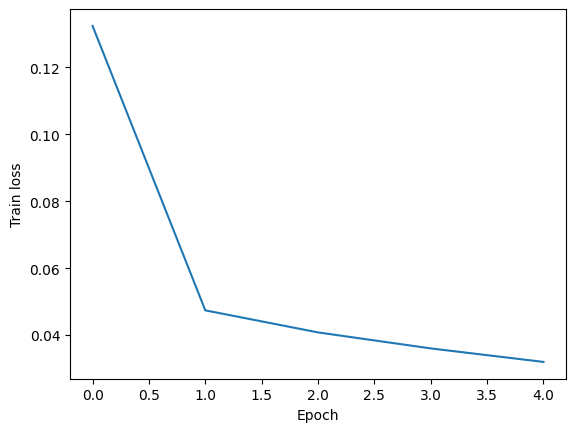

In [5]:
# plot loss
plt.figure()
plt.plot(save_loss)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.show()

In [17]:
checkpoint = torch.load('./encoder_decoder_test/checkpoint_mouse_cross_entropy_4_chan_bs_4.pth', map_location=device)

encoder.load_state_dict(checkpoint['encoder_state_dict'])
decoder.load_state_dict(checkpoint['decoder_state_dict'])

<All keys matched successfully>

In [18]:
# Evaluate model performance
# Dataset path
test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/test/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]

# Create dataset and dataloader
test_dataset = Segmentation3DDataset(image_paths=test_paths)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

encoder.eval()
decoder.eval()

save_latent_e = []
save_recon = []
test_loss = 0


for batch in test_loader:
    batch = batch.to(device)  # (B, C, D, H, W)

    # Forward pass
    batch = batch.to(torch.float)
    z = encoder(batch)
    recon = decoder(z)

    # Compute loss
    loss = criterion(recon, batch.squeeze(1).to(torch.long))
    test_loss += loss.item()

    recon = torch.argmax(recon, dim=1)

    save_latent_e.append(z.detach().cpu())
    save_recon.append(recon.detach().cpu())


    
    


In [3]:
def plot_img(img_arr, slice_idx, title="", cmap="gray"):
    plt.figure(figsize=(3,3))
    plt.imshow(img_arr[slice_idx, :, :], cmap)
    plt.title(title)
    plt.colorbar()
    plt.show()

test loss: 0.03047445951960981
latent shape: (1, 128, 32, 30, 30)
truth shape (128, 120, 120)
recon shape (128, 120, 120)


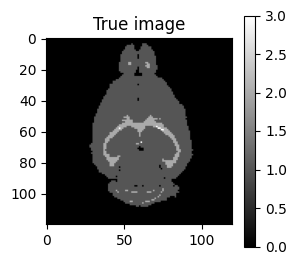

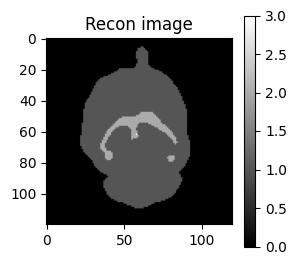

truth shape (128, 120, 120)
recon shape (128, 120, 120)


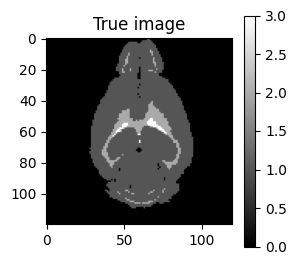

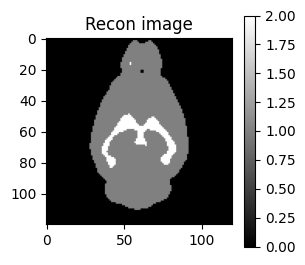

truth shape (128, 120, 120)
recon shape (128, 120, 120)


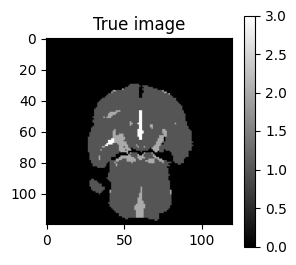

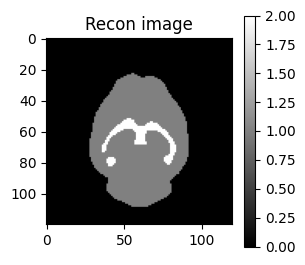

truth shape (128, 120, 120)
recon shape (128, 120, 120)


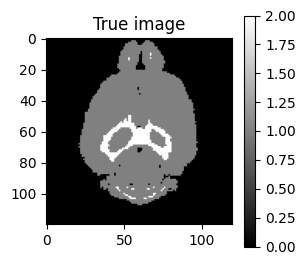

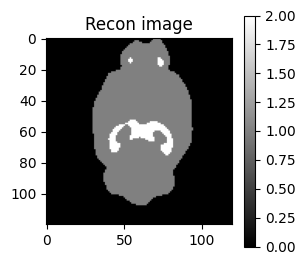

truth shape (128, 120, 120)
recon shape (128, 120, 120)


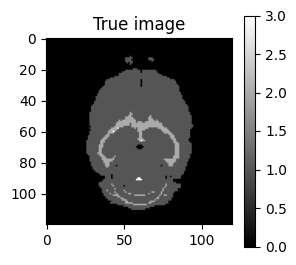

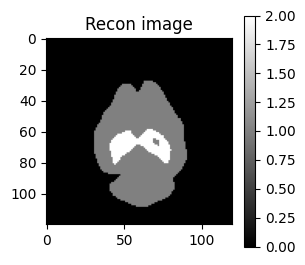

In [21]:
# plot a original versus recon image
print("test loss:", test_loss / len(test_loader))
print("latent shape:", np.array(save_latent_e[0]).shape)

for idx in range(5):
    truth_img = sitk.GetArrayFromImage(sitk.ReadImage(test_paths[idx]))
    recon_img = np.array(save_recon[idx]).squeeze()

    print("truth shape", truth_img.shape)
    print("recon shape", recon_img.shape)

    slice_idx = 50
    plot_img(truth_img, slice_idx, "True image")
    plot_img(recon_img, slice_idx, "Recon image")

Evaluate trained encoder/decoder preformance

In [ ]:


# plot loss
plt.figure()
plt.plot(save_loss)
plt.plot(save_loss)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.show()

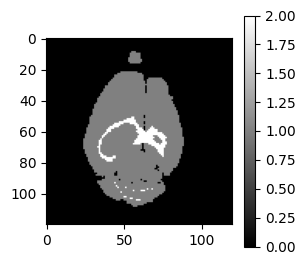

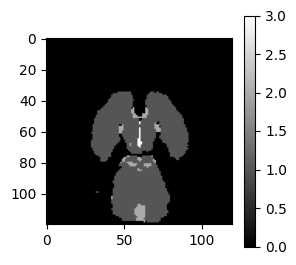

In [25]:
idx = 2
train_save_folder = "./save_models/mouse_train_1/"
epoch = 190
slice_idx = 80

test_folder = "../3D-CycleGan-Pytorch-MedImaging/Data_folder_train_2/train/images/"
test_paths = [test_folder + file_name for file_name in os.listdir(test_folder)]


truth_img = sitk.GetArrayFromImage(sitk.ReadImage(test_paths[idx]))
recon_img = sitk.GetArrayFromImage(sitk.ReadImage(train_save_folder + "test_images/img_" + str(idx) + "_epoch_" + str(epoch) + ".nii"))

plot_img(truth_img, slice_idx)
plot_img(recon_img, slice_idx)
